# 3 · The seven models

Each section gives the idea, the hyperparameters the paper selected and where they come
from, and a call that trains the model and evaluates it on the **test** split (FV1 = RSSI only).

Training every model from scratch on a 4-core CPU takes about 1–2 h in total; SVR and the two
CNNs take the longest. `experiment.run` therefore **caches** each result in `results/runs/`.
If a result is already there it is loaded, so the notebook runs in seconds. Set `FORCE = True`
to retrain.

All models share one interface (`lora_loc/models.py`):
```python
model = models.build("XGBoost")
model.fit(X_train, y_train, X_val, y_val)   # targets are scaled [lat, lon]
y_hat = model.predict(X_test)
```

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   # make `lora_loc` importable from notebooks/
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lora_loc import config, data, preprocessing as pp, features, geo, plotting
plotting.style()
pd.set_option("display.precision", 2)
from lora_loc import models, experiment, paper_results as paper

FORCE = False
FV = "FV1"
d = experiment.prepare_fv(FV)
results = {}

def report(name):
    r = experiment.run(name, FV, prepared=d, force=FORCE, verbose=False)
    results[name] = r
    m = r["metrics"]
    ref = paper.MEAN_ERROR_M.loc[name, FV]
    print(f"{name:9s} mean {m['mean_m']:7.2f} m  (paper {ref:.2f} m, Δ {m['mean_m']-ref:+.2f})  "
          f"median {m['median_m']:6.2f} m  SD {m['sd_m']:6.2f} m  "
          f"R² lat/lon {m['r2_lat']:.4f}/{m['r2_lon']:.4f}  train {m['train_s']:.0f} s")

## 3.1 k-Nearest Neighbours (k-NN)

The classic fingerprinting baseline. It stores all training fingerprints and predicts the
**mean position of the $k$ closest ones**:

$$\hat{\mathbf p}(\mathbf x)=\frac1k\sum_{i\in\mathcal N_k(\mathbf x)}\mathbf p_i,\qquad
d_p(\mathbf x,\mathbf x')=\Big(\sum_g |x_g-x'_g|^p\Big)^{1/p}.$$

The paper's grid (Table 1) searched $k\in\{3,5,7,11\}$ and Manhattan / Euclidean / Chebyshev /
cosine distances. The best was **Manhattan ($p=1$), $k=11$ → 338.56 m**. Manhattan is less
dominated by one large per-gateway difference than Euclidean. That helps here, because
"heard vs. not heard" produces exactly such large jumps.

k-NN is cheap to train, so we can reproduce the **whole of Table 1**:

In [2]:
from sklearn.neighbors import KNeighborsRegressor
metrics = {"Manhattan": dict(p=1), "Euclidean": dict(p=2), "Chebyshev": dict(metric="chebyshev"),
           "Cosine": dict(metric="cosine", algorithm="brute")}
cache = config.RESULTS_DIR / "knn_grid_table1.csv"
if cache.exists() and not FORCE:
    grid = pd.read_csv(cache, index_col=0)
else:
    grid = pd.DataFrame(index=list(metrics), columns=[3, 5, 7, 11], dtype=float)
    for mname, kw in metrics.items():
        for k in grid.columns:
            knn = KNeighborsRegressor(n_neighbors=int(k), n_jobs=-1, **kw).fit(d.X_train, d.y_train)
            err = geo.distance_errors_m(d.y_test_deg, d.pipeline.unscale_y(knn.predict(d.X_test)))
            grid.loc[mname, k] = err.mean()
    grid.to_csv(cache)
grid.columns = [f"k={c}" for c in grid.columns]
paper_t1 = pd.DataFrame({"k=3": [360.26, 362.53, 371.10, 381.90], "k=5": [347.36, 349.98, 358.65, 363.08],
                         "k=7": [342.62, 344.50, 354.39, 360.23], "k=11": [338.56, 340.75, 350.40, 352.74]},
                        index=["Manhattan", "Euclidean", "Chebyshev", "Cosine"])
print("Reproduced mean error (m):"); display(grid.round(2))
print("Paper, Table 1 (m):"); display(paper_t1)

Reproduced mean error (m):


,k=3,k=5,k=7,k=11
Manhattan,358.08,345.42,340.85,336.51
Euclidean,358.65,346.38,340.75,335.96
Chebyshev,371.20,359.10,353.60,350.02
Cosine,362.86,346.53,340.80,336.83


Paper, Table 1 (m):


,k=3,k=5,k=7,k=11
Manhattan,360.26,347.36,342.62,338.56
Euclidean,362.53,349.98,344.50,340.75
Chebyshev,371.10,358.65,354.39,350.40
Cosine,381.90,363.08,360.23,352.74


In [3]:
report("k-NN")

k-NN      mean  336.51 m  (paper 338.56 m, Δ -2.05)  median 207.01 m  SD 414.76 m  R² lat/lon 0.9441/0.8826  train 0 s


## 3.2 Support Vector Regression (SVR)

SVR fits a function that stays within an $\varepsilon$-tube around the targets while keeping the
model as simple as possible:

$$\min_{w,b}\ \tfrac12\lVert w\rVert^2 + C\sum_i(\xi_i+\xi_i^*)\quad\text{s.t.}\quad
|y_i - w^\top\phi(\mathbf x_i) - b|\le\varepsilon+\xi_i^{(*)}.$$

With the RBF kernel $K(\mathbf x,\mathbf x')=\exp(-\gamma\lVert\mathbf x-\mathbf x'\rVert^2)$ the
fitted function is a weighted sum of Gaussian bumps centred on support vectors. SVR has a
single output, so there are **two models**, SVR-LAT and SVR-LON.
Final values (Table 4): **RBF, $C=0.3$, $\varepsilon=0.01$** (in scaled-target units).
The paper does not report $\gamma$, so we use scikit-learn's default `"scale"`.
Training time grows with $n^2$ or worse, which makes this the slowest model on the full 91k set.

In [4]:
report("SVR")

SVR       mean  334.35 m  (paper 331.92 m, Δ +2.43)  median 204.88 m  SD 394.86 m  R² lat/lon 0.9472/0.8905  train 4236 s


## 3.3 Artificial Neural Network (ANN)

A fully connected network, $\mathbb R^{44}\to\mathbb R^2$, with ReLU hidden layers of
**256–256–128–64** units, each followed by **Dropout(0.1)**, and a linear 2-unit output. Training
uses Adam with batch size 64 and MSE loss, for up to 150 epochs, with **early stopping** (patience 10
on validation loss). The architecture comes from the paper's Table 5 search. The paper does not
state the learning rate; we use 1e-4, the value in the authors' supplementary notebook.

In [5]:
report("ANN")

ANN       mean  354.43 m  (paper 332.74 m, Δ +21.69)  median 248.34 m  SD 392.32 m  R² lat/lon 0.9454/0.8846  train 206 s


## 3.4 1-D Convolutional Neural Network (CNN)

The 44-gateway vector is treated as a 1-D sequence:
`Conv1D(32, k=3) → Conv1D(64, k=3) → Flatten → Dense(128, ReLU) → Dropout(0.2) → Dense(2)`,
trained with Adam (lr = 1e-3) for 100 epochs, batch 32 (Table 2).

*A critical remark for students:* a convolution assumes that neighbouring inputs are related.
Here the neighbours are `BS 4`, `BS 5`, …, which are dataset column indices, **not** spatial
neighbours. The CNN therefore cannot exploit real locality. In the paper it is the weakest model
on FV1 (343.88 m, worse than the plain ANN and all tree models), and in our reproduction it does
not beat the tree models either.

In [6]:
report("CNN")

CNN       mean  354.01 m  (paper 343.88 m, Δ +10.13)  median 244.89 m  SD 386.32 m  R² lat/lon 0.9461/0.8872  train 1559 s


## 3.5 XGBoost

Gradient-boosted decision trees. Tree $t$ is fit to the gradient of the loss with respect to the
current ensemble's prediction, and the prediction is $\hat y=\sum_t \eta\, f_t(\mathbf x)$.
Trees split on thresholds such as "RSSI at BS 14 > −112 dBm". That suits sparse fingerprints
naturally, and it is invariant to the monotone log transform.
Final values (Table 6): **400 trees, depth 12, $\eta=0.05$**, early stopping (10 rounds) on the
validation RMSE. One multi-output model predicts both coordinates.

In [7]:
report("XGBoost")

XGBoost   mean  328.30 m  (paper 327.66 m, Δ +0.64)  median 207.52 m  SD 398.18 m  R² lat/lon 0.9478/0.8905  train 62 s


## 3.6 LightGBM

Also gradient boosting, but trees grow **leaf-wise** (the leaf with the largest loss reduction is
split next) on histogram-binned features, which makes it fast on large tabular data. There are two
models, LAT and LON.
Final values (Tables 7–8): **400 leaves, $\eta=0.02$, 1000 trees**, colsample 0.8, L1 = L2 = 0.1.

> The paper also lists `subsample = 0.8`. In LightGBM row subsampling only takes effect if
> `subsample_freq > 0`, which neither the paper nor the authors' code sets. It was therefore
> *not* active, and we keep it off (`config.LGBM`) to match.

In [8]:
report("LightGBM")

LightGBM  mean  326.75 m  (paper 325.43 m, Δ +1.32)  median 210.55 m  SD 394.75 m  R² lat/lon 0.9490/0.8911  train 21 s


## 3.7 Hybrid: CNN feature extractor + XGBoost

The paper's proposed model (Eq. 8):
1. train a CNN `Conv1D(32) → Conv1D(64) → Flatten → Dense(64, ReLU) → Dense(2)` for 100 epochs;
2. take the 64-dimensional `Dense(64)` activations as a learned embedding $\mathbf z$;
3. train XGBoost (400 trees, depth 12, $\eta=0.09$) on $\tilde{\mathbf x}=[\mathbf x;\mathbf z]$,
   one model per coordinate.

The idea is that the CNN learns smooth non-linear combinations of gateways, and the trees handle the
sharp heard / not-heard splits. **Assumptions** (not stated in the paper): kernel size 3, CNN
learning rate 1e-3, and temporal window $T=1$ (Eq. 7 mentions a window of $T$ messages but never
gives $T$).

In [9]:
report("Hybrid")

Hybrid    mean  327.64 m  (paper 323.38 m, Δ +4.26)  median 202.02 m  SD 402.34 m  R² lat/lon 0.9474/0.8890  train 990 s


## 3.8 Summary on FV1 (RSSI only)

,ours mean (m),paper mean (m),Δ (m),ours median (m),ours SD (m),train (s)
model,,,,,,
k-NN,336.51,338.56,-2.05,207.01,414.76,0.00
CNN,354.01,343.88,10.13,244.89,386.32,1558.79
SVR,334.35,331.92,2.43,204.88,394.86,4236.17
ANN,354.43,332.74,21.69,248.34,392.32,205.92
XGBoost,328.30,327.66,0.64,207.52,398.18,61.57
LightGBM,326.75,325.43,1.32,210.55,394.75,20.93
Hybrid,327.64,323.38,4.26,202.02,402.34,990.01


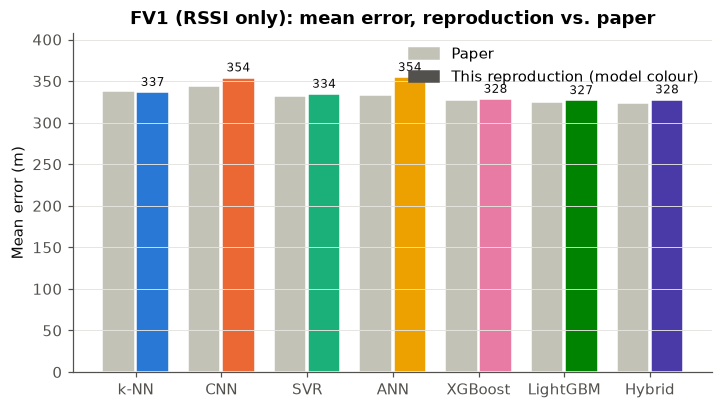

In [10]:
rows = []
for name in models.MODEL_NAMES:
    m = results[name]["metrics"]
    rows.append({"model": name, "ours mean (m)": m["mean_m"], "paper mean (m)": paper.MEAN_ERROR_M.loc[name, FV],
                 "Δ (m)": m["mean_m"] - paper.MEAN_ERROR_M.loc[name, FV], "ours median (m)": m["median_m"],
                 "ours SD (m)": m["sd_m"], "train (s)": m["train_s"]})
summary = pd.DataFrame(rows).set_index("model")
display(summary.round(2))
ours = summary["ours mean (m)"]
plotting.compare_bars(ours, paper.MEAN_ERROR_M[FV], title="FV1 (RSSI only): mean error, reproduction vs. paper")
plt.ylim(0, max(ours.max(), 350) * 1.15); plt.show()

→ **Notebook 4** looks at the full error distributions, FV2, error maps and timing.